In [3]:
import pandas as pd

df = pd.read_csv("/home/ubuntu/cur/program/Teaching/1/サンプルコード/1-3/output_solar_geocoded_500kW_plus_level6minus.csv")

In [4]:
# 件数（行数）とその10%
n = len(df)
tenPercent = n * 0.1
print(f"件数: {n}")
print(f"10%: {tenPercent}")
# 整数が欲しい場合（切り捨て / 四捨五入）
print(f"10%（切り捨て）: {int(n * 0.1)}")
print(f"10%（四捨五入）: {round(n * 0.1)}")

件数: 5252
10%: 525.2
10%（切り捨て）: 525
10%（四捨五入）: 525


In [6]:
a = 2
print(f"aは{a}です。")
print(f"aは{a+2}です。")

aは2です。
aは4です。


In [16]:
df.head()

,設備ID,発電事業者名,代表者名,事業者の住所,事業者の電話番号,発電設備区分,発電出力_kW,発電設備の所在地_代表住所,発電設備の所在地_他の筆数,太陽電池の合計出力_kW,...,source_prefecture_code,source_prefecture_name,source_period,source_note,longitude,latitude,matched,match_level,match_fullname,geocode_status
0,A515991A01,株式会社エネコープ,五十里 浩輔,北海道札幌市中央区北八条西１８丁目３５－１００,011-351-0900,太陽光,1000.0,北海道帯広市南町６線４８－１,0,1000.0,...,1,北海道,202601,※複数住所を持つ設備について、代表住所以外の筆数は「すべての設備所在地」シートを参照してください,143.164505,42.892212,北海道帯広市南町,5,"[""北海道"", ""帯広市"", ""南町""]",ok
1,A516350A01,宮本商産株式会社,平 征浩,帯広市西二条南５丁目１番地,0155-23-2991,太陽光,1495.0,北海道中川郡幕別町４３－１他,0,1502.8,...,1,北海道,202601,※複数住所を持つ設備について、代表住所以外の筆数は「すべての設備所在地」シートを参照してください,143.356079,42.908199,北海道中川郡幕別町,3,"[""北海道"", ""中川郡"", ""幕別町""]",ok
2,A517798A01,王子グリーンエナジー白糠株式会社,早瀬 祐一,東京都中央区銀座４－７－５,NaN,太陽光,1250.0,北海道白糠郡白糠町西庶路西四条南１,0,1250.0,...,1,北海道,202601,※複数住所を持つ設備について、代表住所以外の筆数は「すべての設備所在地」シートを参照してください,144.119339,42.972668,北海道白糠郡白糠町西庶路西四条南１,6,"[""北海道"", ""白糠郡"", ""白糠町"", ""西庶路西四条"", ""南一丁目""]",ok
3,A517808A01,ＭＳＦ株式会社,代表取締役社長 梅川 真明,北海道帯広市自由が丘五丁目１番２,03-3542-0186,太陽光,1999.5,北海道河東郡上士幌町上士幌字上士幌東２線２８２－１,2,3834.1,...,1,北海道,202601,※複数住所を持つ設備について、代表住所以外の筆数は「すべての設備所在地」シートを参照してください,143.299637,43.330742,北海道河東郡上士幌町上士幌,5,"[""北海道"", ""河東郡"", ""上士幌町"", ""字上士幌""]",ok
4,A518012A01,株式会社エコテック,千葉 浩一,白糠郡白糠町庶路３８－１,01547-5-3138,太陽光,500.0,北海道白糠郡白糠町庶路基線５,0,500.0,...,1,北海道,202601,※複数住所を持つ設備について、代表住所以外の筆数は「すべての設備所在地」シートを参照してください,144.077759,43.060616,北海道白糠郡白糠町庶路基線,5,"[""北海道"", ""白糠郡"", ""白糠町"", ""庶路基線""]",ok


/tmp/ipykernel_666918/3075789410.py:28: UserWarning: Glyph 35373 (\N{CJK UNIFIED IDEOGRAPH-8A2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_666918/3075789410.py:28: UserWarning: Glyph 20633 (\N{CJK UNIFIED IDEOGRAPH-5099}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_666918/3075789410.py:28: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_666918/3075789410.py:28: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_666918/3075789410.py:28: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_666918/3075789410.py:28: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_666918/3075789410.py:28: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH

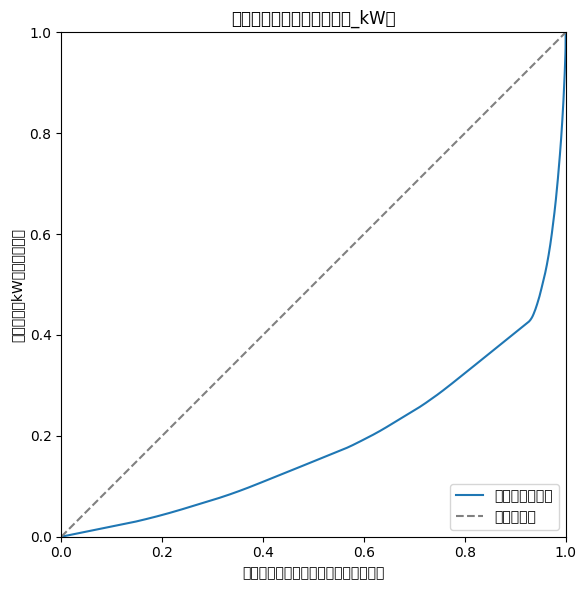

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

col = "発電出力_kW"
values = df[col].dropna().to_numpy(dtype=float)
values.sort()

total = values.sum()
if total <= 0 or len(values) == 0:
    raise ValueError("発電出力_kW に有効な正の合計がありません")

# 横軸: 設備（行）を出力の小さい順に並べたときの累積件数比率、縦軸: 累積出力比率
cum_share = np.cumsum(values) / total
n = len(values)
x = np.concatenate([[0.0], np.arange(1, n + 1) / n])
y = np.concatenate([[0.0], cum_share])

fig, ax = plt.subplots(figsize=(6, 6))
# errorbar=None で信頼区間帯を出さない（ローレンツ曲線は1本の折れ線として描く）
sns.lineplot(x=x, y=y, ax=ax, label="ローレンツ曲線", errorbar=None)
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    ax=ax,
    linestyle="--",
    color="gray",
    label="完全平等線",
    errorbar=None,
)
ax.set_xlabel("設備数の累積比率（出力の小さい順）")
ax.set_ylabel("発電出力（kW）の累積比率")
ax.set_title(f"ローレンツ曲線（{col}）")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()